### Importação dos dados



In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_1.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_4.csv"

loja = pd.read_csv(url)
loja2 = pd.read_csv(url2)
loja3 = pd.read_csv(url3)
loja4 = pd.read_csv(url4)

loja.head()

,Produto,Categoria do Produto,Preço,Frete,Data da Compra,Vendedor,Local da compra,Avaliação da compra,Tipo de pagamento,Quantidade de parcelas,lat,lon
0,Assistente virtual,eletronicos,219.08,9.249790,16/01/2021,Pedro Gomes,SP,4,cartao_credito,8,-22.19,-48.79
1,Mesa de jantar,moveis,256.35,11.234305,18/05/2022,Beatriz Moraes,RJ,1,cartao_credito,4,-22.25,-42.66
2,Jogo de tabuleiro,brinquedos,279.51,21.262681,15/03/2021,João Souza,DF,1,cartao_credito,1,-15.83,-47.86
3,Micro-ondas,eletrodomesticos,1009.99,54.667344,03/05/2022,João Souza,RS,4,boleto,1,-30.17,-53.50
4,Cadeira de escritório,moveis,446.99,26.964689,07/11/2020,Larissa Alves,MG,5,boleto,1,-18.10,-44.38


#1. Análise do faturamento



In [ ]:
# 1. CRIAR A COLUNA 'Loja' para marcar a origem dos dados
# Estamos assumindo que as variáveis são: loja1, loja2, loja3, loja4

loja ['Loja'] = 'Loja 1'
loja2['Loja'] = 'Loja 2'
loja3['Loja'] = 'Loja 3'
loja4['Loja'] = 'Loja 4'

# 2. COMBINAR todos os DataFrames em um único, chamado df_total

df_total = pd.concat([loja, loja2, loja3, loja4], ignore_index=True)

print("Dados das 4 lojas unificados no DataFrame 'df_total'.")

Dados das 4 lojas unificados no DataFrame 'df_total'.


In [ ]:
# 3. CALCULAR O FATURAMENTO TOTAL POR LOJA
# Agrupando pelo nome da loja e somando a coluna 'Preço'

faturamento_por_loja = df_total.groupby('Loja')['Preço'].sum().sort_values(ascending=False)

print("\n💰 Faturamento Total de Cada Loja:")

# NOVO BLOCO DE FORMATAÇÃO E IMPRESSÃO

faturamento_formatado = faturamento_por_loja.apply(lambda x: f'R$ {x:,.2f}'.replace(',', 'X').replace('.', ',').replace('X', '.'))

print(faturamento_formatado)


💰 Faturamento Total de Cada Loja:
Loja
Loja 1    R$ 1.534.509,12
Loja 2    R$ 1.488.459,06
Loja 3    R$ 1.464.025,03
Loja 4    R$ 1.384.497,58
Name: Preço, dtype: object


# 2.1 Vendas por Categoria Mais Vendido

In [ ]:
print("--- Análise da Quantidade de Vendas por Categoria ---")

# 1. Agrupar por 'Loja' e 'Categoria do Produto' e contar o número de vendas (linhas)

vendas_por_categoria = df_total.groupby(['Loja', 'Categoria do Produto']).size().reset_index(name='Total de Vendas')

# 2. Encontrar a categoria mais vendida em cada loja (opcional, mas muito útil!)
# Ordenamos por Loja e por Total de Vendas (decrescente)

vendas_por_categoria_ordenada = vendas_por_categoria.sort_values(
    by=['Loja', 'Total de Vendas'],
    ascending=[True, False]
)

# 3. Exibir o resultado
# Para não mostrar a lista completa (que pode ser longa), vamos mostrar apenas o Top 5 de Vendas Gerais

print("\n📋 Top 5 Categorias Mais Vendidas (Geral):")
print(vendas_por_categoria.sort_values(by='Total de Vendas', ascending=False).head(5))

# Para focar na sua análise: Mostrar as categorias de cada loja

print("\n📦 Top Categorias em CADA Loja:")
# Usamos o .head(1) em um novo agrupamento para pegar apenas a mais vendida de cada loja

top_categoria_por_loja = vendas_por_categoria_ordenada.groupby('Loja').head(1)
print(top_categoria_por_loja)


--- Análise da Quantidade de Vendas por Categoria ---

📋 Top 5 Categorias Mais Vendidas (Geral):
      Loja Categoria do Produto  Total de Vendas
22  Loja 3               moveis              499
30  Loja 4               moveis              480
6   Loja 1               moveis              465
26  Loja 4          eletronicos              451
18  Loja 3          eletronicos              451

📦 Top Categorias em CADA Loja:
      Loja Categoria do Produto  Total de Vendas
6   Loja 1               moveis              465
14  Loja 2               moveis              442
22  Loja 3               moveis              499
30  Loja 4               moveis              480


# 2.2 Vendas por Categoria Menos Vendido

In [ ]:
print("--- Análise da Quantidade de Vendas por Categoria ---")

# Limpar possíveis espaços nos nomes das colunas
df_total.columns = df_total.columns.str.strip()

# Agrupar
vendas_por_categoria = df_total.groupby(
    ['Loja', 'Categoria do Produto']
).size().reset_index(name='Total de Vendas')

# Ordenar crescente (menos vendidas)
vendas_por_categoria_ordenada = vendas_por_categoria.sort_values(
    by=['Loja', 'Total de Vendas'],
    ascending=[True, True]
)

print("\n📋 Top 5 Categorias MENOS Vendidas (Geral):")
print(vendas_por_categoria.sort_values(
    by='Total de Vendas',
    ascending=True
).head(5))

print("\n📦 Categoria MENOS Vendida em CADA Loja:")
categoria_menos_por_loja = vendas_por_categoria_ordenada.groupby('Loja').head(1)
print(categoria_menos_por_loja)

--- Análise da Quantidade de Vendas por Categoria ---

📋 Top 5 Categorias MENOS Vendidas (Geral):
      Loja   Categoria do Produto  Total de Vendas
28  Loja 4  instrumentos musicais              170
7   Loja 1  utilidades domesticas              171
5   Loja 1                 livros              173
23  Loja 3  utilidades domesticas              177
20  Loja 3  instrumentos musicais              177

📦 Categoria MENOS Vendida em CADA Loja:
      Loja   Categoria do Produto  Total de Vendas
7   Loja 1  utilidades domesticas              171
15  Loja 2  utilidades domesticas              181
20  Loja 3  instrumentos musicais              177
28  Loja 4  instrumentos musicais              170


# 3. Média de Avaliação das Lojas


In [ ]:
# CÉLULA 1: RENOMEAR E SIMPLIFICAR

# Simplificando os nomes das colunas para evitar erros de digitação e acentuação
# Se você tiver que trocar 'Avaliacao da compra' por 'Avaliacao', esta é a célula!
df_total.rename(columns={
    'Categoria do Produto': 'Categoria',
    'Avaliação da compra': 'Avaliacao', # <--- O FOCO AQUI
    'Tipo de pagamento': 'Tipo_Pagamento',
    'Data da Compra': 'Data_Compra',
}, inplace=True)

print("Nomes das colunas simplificados para 'Categoria' e 'Avaliacao'.")

Nomes das colunas simplificados para 'Categoria' e 'Avaliacao'.


In [ ]:
# CÉLULA 2: CÁLCULO DA AVALIAÇÃO MÉDIA

print("--- Análise da Satisfação do Cliente (Avaliação Média) ---")

# Agrupar por 'Loja' e calcular a MÉDIA usando o nome SIMPLIFICADO 'Avaliacao'
avaliacao_media_por_loja = (
    df_total.groupby('Loja')['Avaliacao']
    .mean()
    .round(2)
    .sort_values(ascending=False)
)

print("\n⭐ Avaliação Média (Nota de 1 a 5) de Cada Loja:")
print(avaliacao_media_por_loja)

--- Análise da Satisfação do Cliente (Avaliação Média) ---

⭐ Avaliação Média (Nota de 1 a 5) de Cada Loja:
Loja
Loja 3    4.05
Loja 2    4.04
Loja 4    4.00
Loja 1    3.98
Name: Avaliacao, dtype: float64


# 4. Produtos Mais e Menos Vendidos

In [ ]:
print("--- Análise de Produtos Mais e Menos Vendidos ---")

# 1. Contar a quantidade vendida de CADA produto em CADA loja
# (Assumindo que o nome da coluna de produtos é 'Produto')
vendas_por_produto = (
    df_total.groupby(['Loja', 'Produto'])
    .size() # .size() conta o número de vendas (linhas)
    .reset_index(name='Quantidade_Vendida')
)

# 2. Ordenar para ver o ranking completo de cada loja
vendas_por_produto = vendas_por_produto.sort_values(
    by=['Loja', 'Quantidade_Vendida'],
    ascending=[True, False] # Ordena por Loja (A-Z) e Quantidade (Maior->Menor)
)

# 3. Mostrar os MAIS vendidos (Top 3 de cada loja)
print("\n🏆 Top 3 Produtos MAIS Vendidos em Cada Loja:")
top_3_por_loja = vendas_por_produto.groupby('Loja').head(3)
print(top_3_por_loja)

# 4. Mostrar os MENOS vendidos (Os 3 piores de cada loja)
print("\n📉 Os 3 Produtos MENOS Vendidos em Cada Loja:")
# Para pegar os menos vendidos, usamos .tail(3)
bottom_3_por_loja = vendas_por_produto.groupby('Loja').tail(3)
print(bottom_3_por_loja)

--- Análise de Produtos Mais e Menos Vendidos ---

🏆 Top 3 Produtos MAIS Vendidos em Cada Loja:
       Loja                   Produto  Quantidade_Vendida
24   Loja 1             Guarda roupas                  60
37   Loja 1               Micro-ondas                  60
47   Loja 1             TV Led UHD 4K                  60
79   Loja 2  Iniciando em programação                  65
88   Loja 2               Micro-ondas                  62
52   Loja 2                   Bateria                  61
134  Loja 3             Kit banquetas                  57
111  Loja 3                 Cama king                  56
138  Loja 3            Mesa de jantar                  56
161  Loja 4                  Cama box                  62
173  Loja 4                  Faqueiro                  59
162  Loja 4                 Cama king                  56

📉 Os 3 Produtos MENOS Vendidos em Cada Loja:
       Loja            Produto  Quantidade_Vendida
41   Loja 1  Panela de pressão                  35
11


--- Visualização: Top 3 Produtos Mais Vendidos por Loja (Versão Horizontal) ---


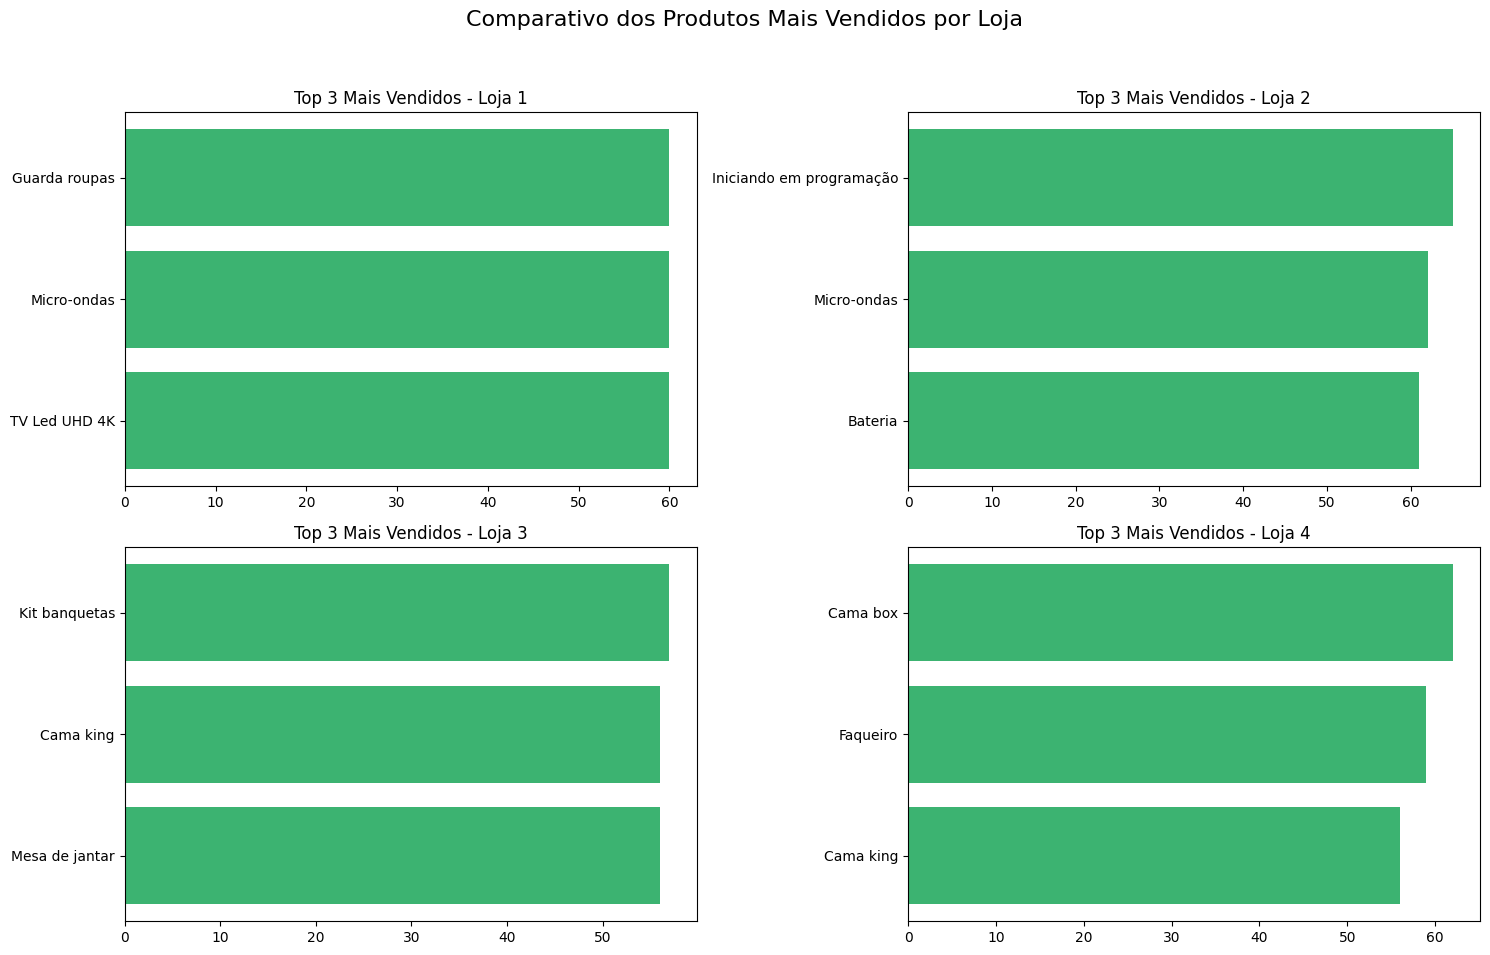

In [ ]:
# Importar a biblioteca de gráficos
import matplotlib.pyplot as plt

print("\n--- Visualização: Top 3 Produtos Mais Vendidos por Loja (Versão Horizontal) ---")

# Vamos usar a variável 'top_3_por_loja' que calculamos antes

# 1. Pegar a lista de lojas (ex: ['Loja 1', 'Loja 2', ...])
lista_lojas = df_total['Loja'].unique()
lista_lojas.sort() # Garante a ordem

# 2. Criar a grade de gráficos (2 linhas, 2 colunas)
# fig = a figura inteira; axs = os 4 eixos (gráficos)
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(15, 10))

# Ajustar os eixos para um array simples (axs[0], axs[1], etc.)
axs = axs.flatten()

# 3. Criar um loop: faz um gráfico para cada loja na lista
for i, loja_nome in enumerate(lista_lojas):

    # Filtrar os dados: pegar o Top 3 APENAS da loja atual
    top_3_desta_loja = top_3_por_loja[top_3_por_loja['Loja'] == loja_nome]

    # Pegar o eixo correto (axs[0] para o primeiro gráfico, axs[1] para o segundo, etc.)
    ax = axs[i]

    # Criar o gráfico de barras HORIZONTAL
    ax.barh(
        top_3_desta_loja['Produto'],
        top_3_desta_loja['Quantidade_Vendida'],
        color='mediumseagreen'
    )

    # Adicionar títulos para CADA gráfico
    ax.set_title(f'Top 3 Mais Vendidos - {loja_nome}')

    # Inverter o eixo Y para que o produto MAIS vendido fique em cima
    ax.invert_yaxis()

# Adicionar um título geral para a figura
fig.suptitle('Comparativo dos Produtos Mais Vendidos por Loja', fontsize=16)

# Ajustar o layout para não sobrepor os títulos
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajusta para o título geral

# Exibir o gráfico
plt.show()

# 5. Frete Médio por Loja

In [ ]:
print("--- Análise do Custo Médio de Frete ---")

# 1. Agrupar por 'Loja' e calcular a MÉDIA (.mean()) da coluna 'Frete'
# Arredondamos para 2 casas decimais (Reais e centavos)
frete_medio_por_loja = (
    df_total.groupby('Loja')['Frete']
    .mean()
    .round(2)
    .sort_values(ascending=True) # Ordenamos ascendentemente para ver o mais barato primeiro
)

print("\n📦 Custo Médio de Frete por Loja:")

# 2. Imprimir com formatação de moeda (R$) para facilitar a leitura
frete_formatado = frete_medio_por_loja.apply(lambda x: f'R$ {x:,.2f}'.replace(',', 'X').replace('.', ',').replace('X', '.'))

print(frete_formatado)

--- Análise do Custo Médio de Frete ---

📦 Custo Médio de Frete por Loja:
Loja
Loja 4    R$ 31,28
Loja 3    R$ 33,07
Loja 2    R$ 33,62
Loja 1    R$ 34,69
Name: Frete, dtype: object


--- GRÁFICO 1: Faturamento Total por Loja ---


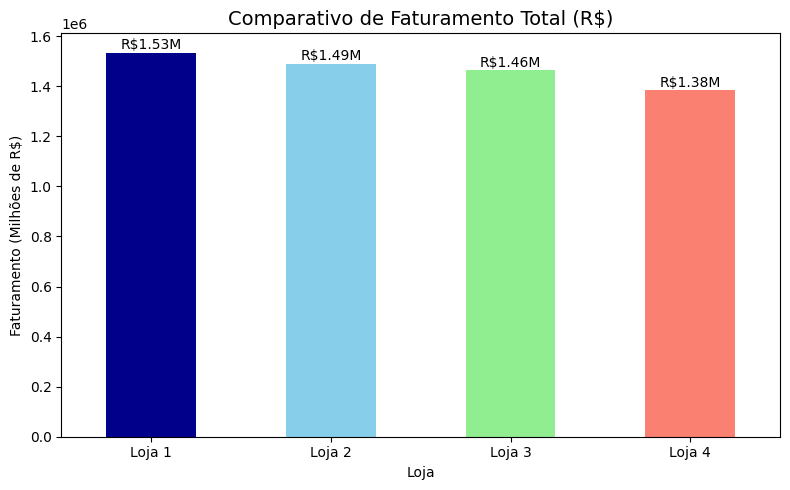

In [ ]:
import matplotlib.pyplot as plt

print("--- GRÁFICO 1: Faturamento Total por Loja ---")

# Você pode rodar isso em uma nova célula. Usamos a variável de faturamento já calculada.
plt.figure(figsize=(8, 5))
faturamento_por_loja.plot(kind='bar', color=['darkblue', 'skyblue', 'lightgreen', 'salmon']) # Cores diferentes para cada barra
plt.title('Comparativo de Faturamento Total (R$)', fontsize=14)
plt.xlabel('Loja')
plt.ylabel('Faturamento (Milhões de R$)')
plt.xticks(rotation=0) # Rótulos retos para melhor leitura

# Adicionar o valor exato no topo de cada barra (opcional, mas profissional)
for index, value in enumerate(faturamento_por_loja.values):
    plt.text(index, value + (value*0.01), f'R${value/1000000:.2f}M', ha='center')

plt.tight_layout() # Ajusta o gráfico
plt.show()

--- GRÁFICO 2: Avaliação Média vs. Faturamento ---


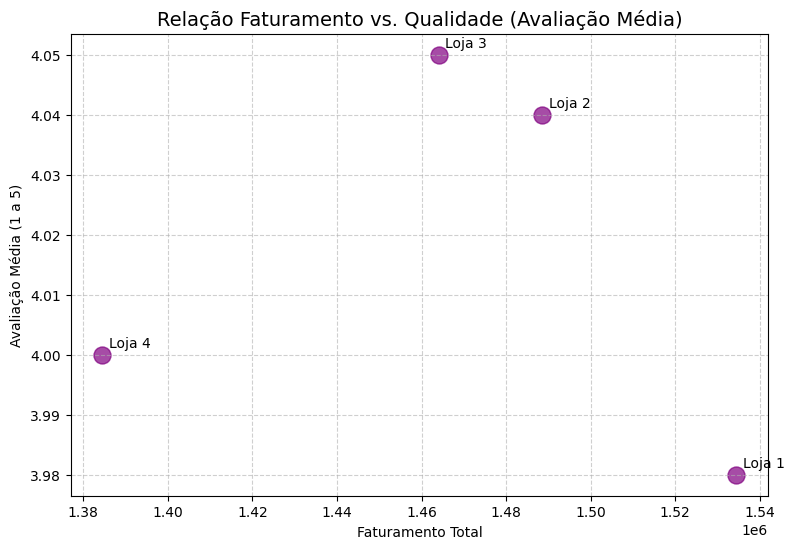

In [ ]:
print("--- GRÁFICO 2: Avaliação Média vs. Faturamento ---")

# 1. Alinhar os dados em um DataFrame de resumo
df_resumo = pd.DataFrame({
    'Faturamento': faturamento_por_loja,
    'Avaliacao': avaliacao_media_por_loja
}).reset_index()

# 2. Criar o gráfico de dispersão
plt.figure(figsize=(9, 6))
plt.scatter(df_resumo['Faturamento'], df_resumo['Avaliacao'], s=150, alpha=0.7, color='purple')

plt.title('Relação Faturamento vs. Qualidade (Avaliação Média)', fontsize=14)
plt.xlabel('Faturamento Total')
plt.ylabel('Avaliação Média (1 a 5)')
plt.grid(True, linestyle='--', alpha=0.6)

# 3. Adicionar o nome da Loja ao lado de cada ponto (SUPER IMPORTANTE!)
for i in range(df_resumo.shape[0]):
    plt.annotate(
        df_resumo['Loja'][i],
        (df_resumo['Faturamento'][i], df_resumo['Avaliacao'][i]),
        xytext=(5, 5),
        textcoords='offset points'
    )

plt.show()

--- GRÁFICO 3: Proporção do Custo Médio de Frete ---


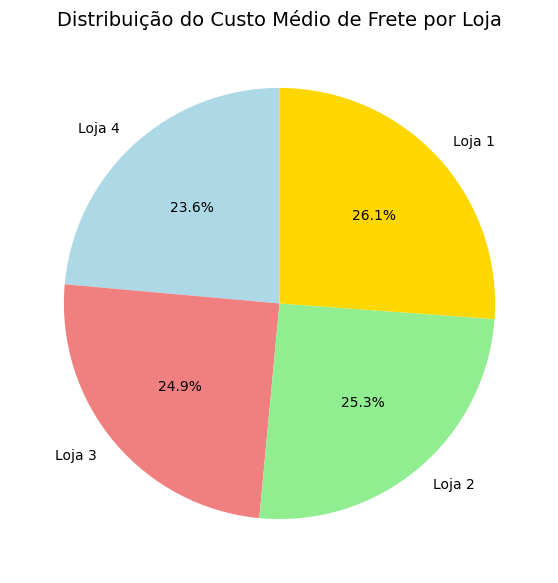

In [ ]:
print("--- GRÁFICO 3: Proporção do Custo Médio de Frete ---")

# Usamos a variável de frete médio já calculada
plt.figure(figsize=(7, 7))
plt.pie(
    frete_medio_por_loja,
    labels=frete_medio_por_loja.index,
    autopct='%1.1f%%', # Mostra o percentual com uma casa decimal
    startangle=90,
    colors=['lightblue', 'lightcoral', 'lightgreen', 'gold']
)
plt.title('Distribuição do Custo Médio de Frete por Loja', fontsize=14)
plt.show()

--- DESAFIO EXTRA: Mapeamento Geográfico das Vendas ---


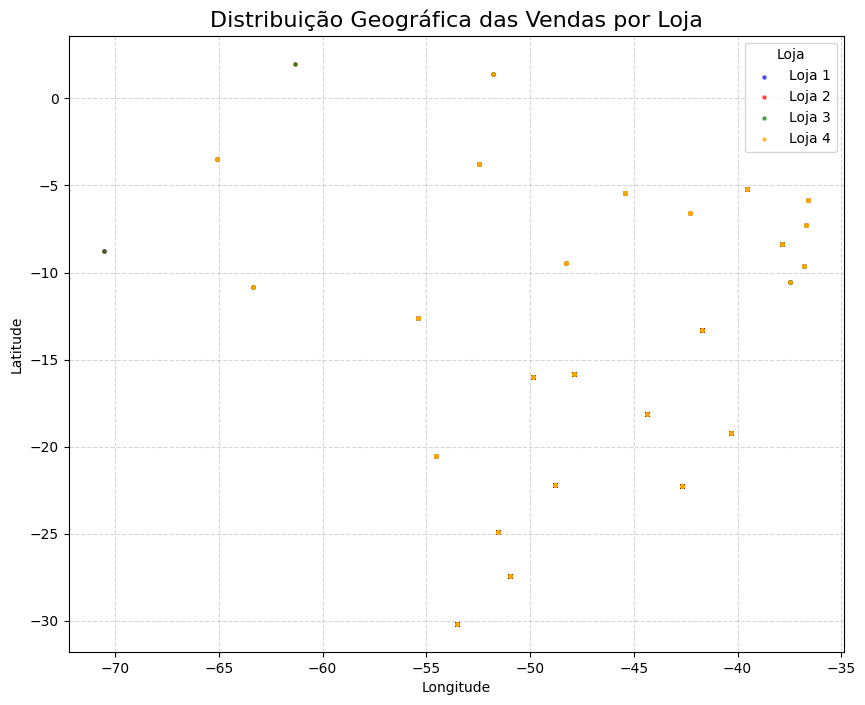

In [ ]:
import matplotlib.pyplot as plt

print("--- DESAFIO EXTRA: Mapeamento Geográfico das Vendas ---")

# 1. Preparar a figura e os eixos
plt.figure(figsize=(10, 8))

# 2. Iterar sobre cada loja para plotar suas vendas com uma cor diferente
lojas = df_total['Loja'].unique()
cores = ['blue', 'red', 'green', 'orange'] # Cores para Loja 1, 2, 3, 4, respectivamente

# Percorrer cada loja e plotar seus pontos de venda no gráfico
for loja, cor in zip(lojas, cores):

    # Filtrar o df_total APENAS para a loja atual
    df_loja = df_total[df_total['Loja'] == loja]

    # Criar o Gráfico de Dispersão (Scatter Plot)
    # lat no Eixo Y e lon no Eixo X (padrão de mapas)
    plt.scatter(
        df_loja['lon'],        # Longitude (Eixo X)
        df_loja['lat'],         # Latitude (Eixo Y)
        s=5,                    # Tamanho pequeno do ponto (cada ponto é uma venda)
        alpha=0.6,              # Transparência para ver a concentração
        c=cor,                  # Cor da loja
        label=loja              # Rótulo para a legenda
    )

# 3. Finalizar o Gráfico
plt.title('Distribuição Geográfica das Vendas por Loja', fontsize=16)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Loja')
plt.grid(True, linestyle='--', alpha=0.5)

# Opcional: Ajustar os limites do mapa para cobrir a área de interesse (Brasil)
# plt.xlim(-80, -30)
# plt.ylim(-35, 5)

plt.show()

# 📊 Relatório Final – Análise de Desempenho das Lojas
---

1️⃣ Introdução

O presente relatório tem como objetivo analisar o desempenho das quatro lojas do Senhor João, considerando os seguintes indicadores:


* Faturamento total
* Categorias mais e menos vendidas
* Produtos mais e menos vendidos
* Média de avaliação dos clientes
* Custo médio de frete

Com base nesses dados, será apresentada uma recomendação estratégica sobre qual loja deve ser vendida, considerando desempenho financeiro, eficiência operacional e percepção dos clientes.



💰 Faturamento Total

* Loja 1: R$ 1.534.509,12

* Loja 2: R$ 1.488.459,06

* Loja 3: R$ 1.464.025,03

* Loja 4: R$ 1.384.497,58


A **Loja 1** apresenta o ***Maior faturamento***.

A **Loja 4** possui o ***Menor faturamento*** entre todas.



# Recomendações Finais.
2️⃣ Desenvolvimento da Análise

Após analisar o desempenho das quatro lojas do Senhor João, foi possível comparar faturamento, volume de vendas, satisfação dos clientes e custo médio de frete para identificar qual unidade apresenta menor desempenho geral.

* A Loja 1 se destaca pelo maior faturamento, mostrando forte capacidade de geração de receita. No entanto, apresenta a menor média de avaliações e o frete mais alto, o que pode impactar a experiência do cliente.

* A Loja 2 mantém um desempenho estável, sem grandes pontos fracos ou destaques negativos.

 * A Loja 3, por sua vez, possui a melhor avaliação entre os consumidores e um bom equilíbrio entre faturamento e custo de frete, demonstrando uma operação eficiente.

* Já a Loja 4 apresenta o menor faturamento entre todas. Apesar de ter o menor custo médio de frete, esse diferencial não foi suficiente para torná-la mais competitiva ou elevar seu volume de vendas em relação às demais. De forma geral, ela não lidera em nenhum dos indicadores analisados.

Diante disso, a recomendação é que o Senhor João ***venda a Loja 4***, pois ela apresenta o *desempenho menos competitivo* no conjunto dos fatores avaliados. Essa decisão permitirá concentrar investimentos e estratégias nas lojas com maior potencial de crescimento e retorno financeiro.


In [ ]:
from google.colab import drive
import pandas as pd

drive.mount('/content/drive')


caminho_salvar = '/content/drive/MyDrive/meu_trabalho_de_dados_concluido.csv'
df_total.to_csv(caminho_salvar, index=False)

print(f"\n✅ SUCESSO! O arquivo foi salvo no seu Google Drive em: {caminho_salvar}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

✅ SUCESSO! O arquivo foi salvo no seu Google Drive em: /content/drive/MyDrive/meu_trabalho_de_dados_concluido.csv
